<a href="https://colab.research.google.com/github/kondapallishanthisudha-maker/image-classification-max-pooling/blob/main/Image_Classification_Using_Max_Pooling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!nvidia-smi

Wed Aug 19 09:26:44 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   52C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np
import cv2
import os

In [ ]:
img = image.load_img('/content/drive/MyDrive/Happy or Sad/Training/happy/1.jpg')

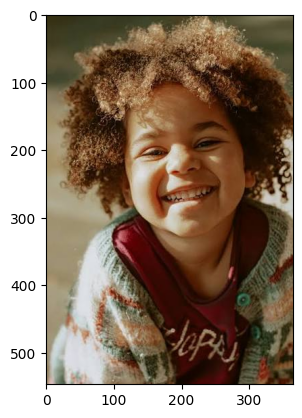

In [ ]:
plt.imshow(img)

In [ ]:
train = ImageDataGenerator(rescale=1/255)
validation = ImageDataGenerator(rescale=1/255)

train_dataset = train.flow_from_directory('/content/drive/MyDrive/Happy or Sad/Training'
                                          ,target_size=(200,200)
                                          ,batch_size= 32
                                          ,class_mode='binary')
validation_dataset = validation.flow_from_directory('/content/drive/MyDrive/Happy or Sad/Validation'
                                          ,target_size=(200,200)
                                          ,batch_size= 32
                                          ,class_mode='binary')

Found 39 images belonging to 2 classes.
Found 0 images belonging to 0 classes.


In [ ]:
train_dataset.class_indices

{'happy': 0, 'not happy': 1}

In [ ]:
train_dataset.classes

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], dtype=int32)

In [ ]:
model = tf.keras.models.Sequential([tf.keras.layers.Conv2D(16,(3,3),activation= 'relu',
                                                           input_shape=(200,200,3)),
                                    tf.keras.layers.MaxPool2D(2,2), #3 filter we applied hear
                                    #
                                    tf.keras.layers.Conv2D(32,(3,3),activation= 'relu'),
                                    tf.keras.layers.MaxPool2D(2,2),
                                    #
                                    tf.keras.layers.Conv2D(64,(3,3),activation= 'relu'),
                                    tf.keras.layers.MaxPool2D(2,2),
                                    ##
                                    tf.keras.layers.Flatten(),
                                    #
                                    tf.keras.layers.Dense(512,activation='relu'),
                                    #
                                    tf.keras.layers.Dense(1,activation='sigmoid')
                                    ])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(loss='binary_crossentropy',
              optimizer = tf.keras.optimizers.RMSprop(learning_rate=0.001),
              metrics=['accuracy'])

In [ ]:
model_fit = model.fit(train_dataset,epochs=20)

Epoch 1/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 9s 3s/step - accuracy: 0.4359 - loss: 3.3308
Epoch 2/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.5128 - loss: 4.1584
Epoch 3/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - accuracy: 0.6667 - loss: 0.6369
Epoch 4/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - accuracy: 0.8205 - loss: 0.5853
Epoch 5/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.6923 - loss: 0.5970 
Epoch 6/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5385 - loss: 0.7454 
Epoch 7/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8205 - loss: 0.5601 
Epoch 8/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - accuracy: 0.4872 - loss: 0.9489
Epoch 9/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - accuracy: 0.7692 - loss: 0.5390
Epoch 10/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8462 - loss: 0.4584 
Epoch 11/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6667 - loss: 0.5126 
Epoch 12/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.7692 - loss: 

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 198, 198, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 99, 99, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 97, 97, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 46, 46, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 33856)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    17,334,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,717,764 (132.44 MB)

 Trainable params: 17,358,881 (66.22 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 17,358,883 (66.22 MB)

In [ ]:
dir_path = '/content/drive/MyDrive/Happy or Sad/Testing'
for i in os.listdir(dir_path):
  print(i)

7.jpg
8.jpg
9.jpg
10.jpg
11.jpg
2.jpg
3.jpg
4.jpg
14.jpg


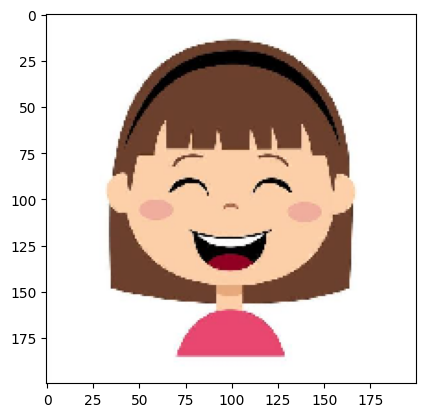

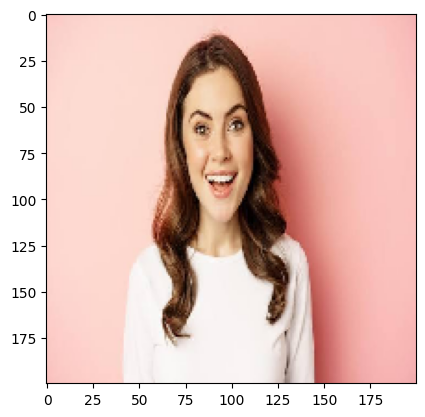

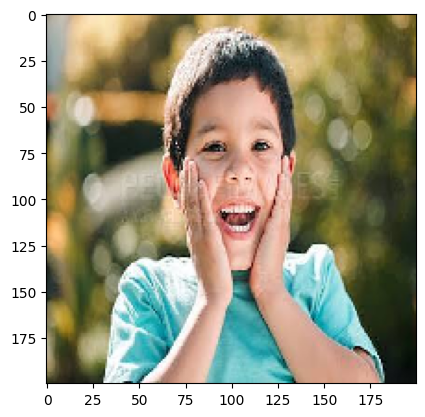

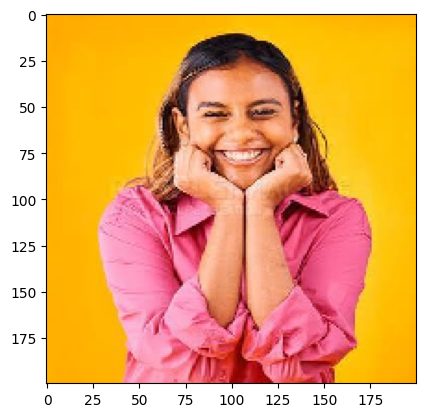

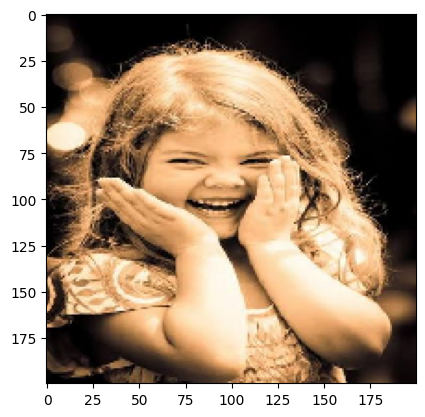

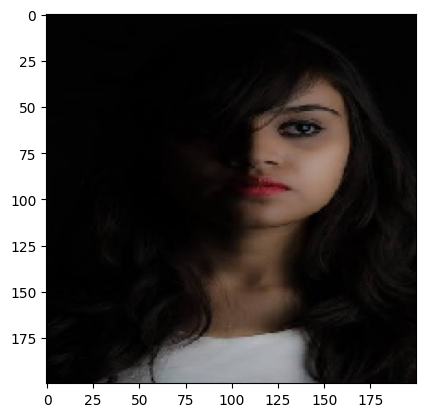

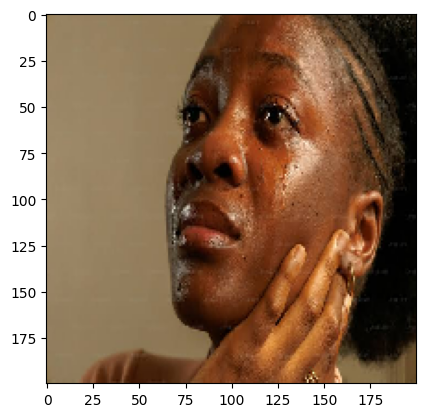

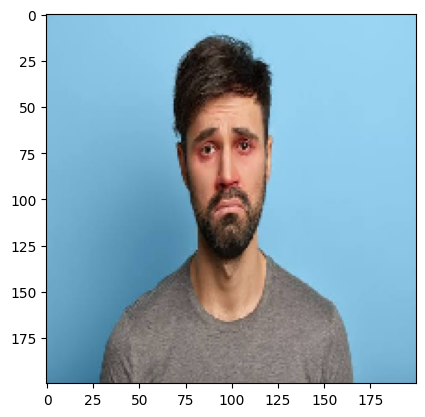

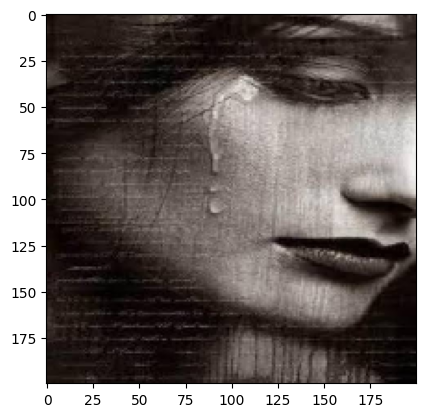

In [ ]:
dir_path = '/content/drive/MyDrive/Happy or Sad/Testing'

for i in os.listdir(dir_path):
  img = image.load_img(dir_path+'//'+i,target_size=(200,200))
  plt.imshow(img)
  plt.show()

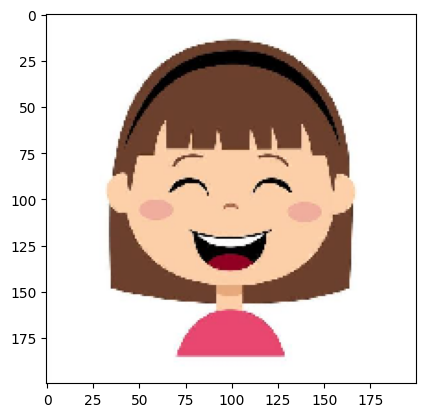

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 839ms/step
 i am happy


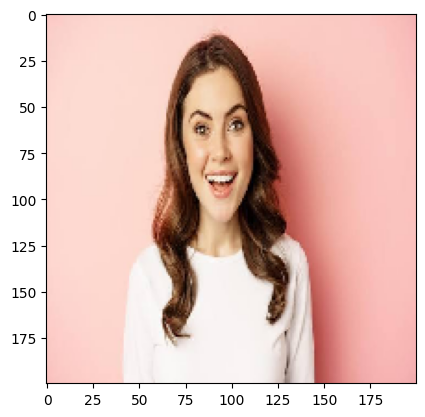

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
 i am happy


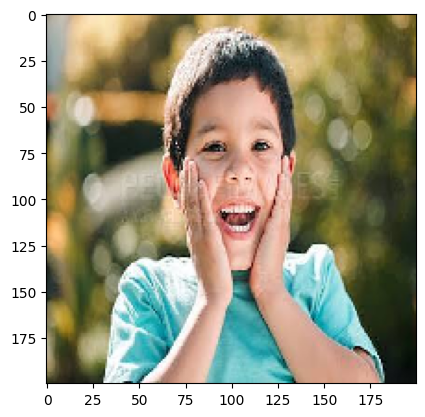

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
 i am happy


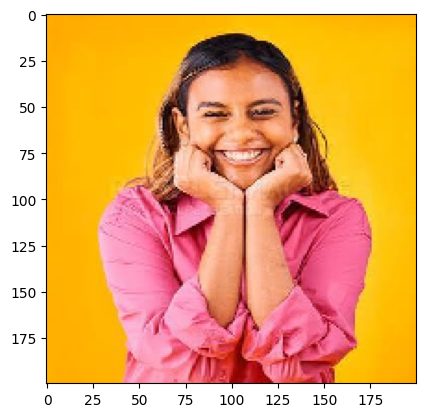

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
 i am happy


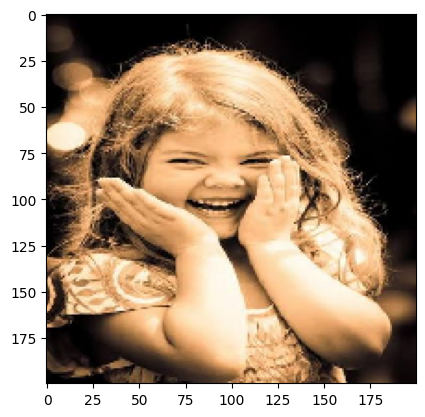

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
 i am happy


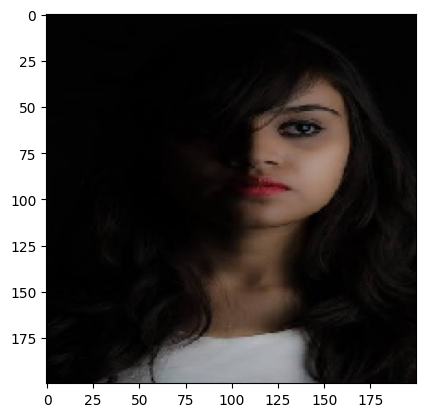

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
 i am not happy


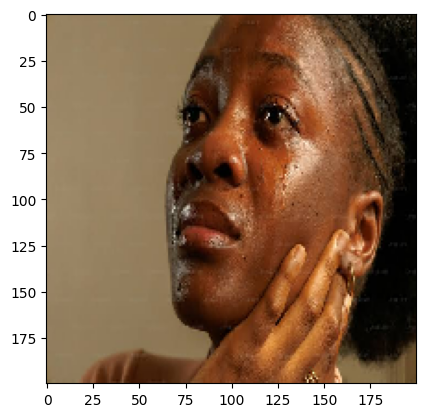

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
 i am happy


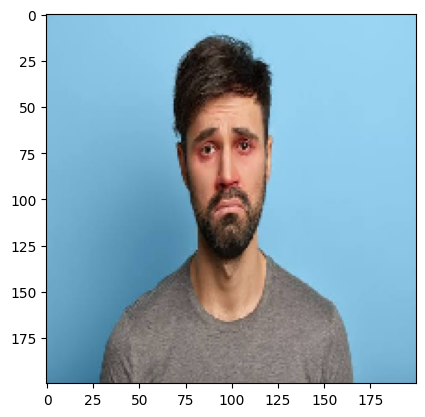

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
 i am happy


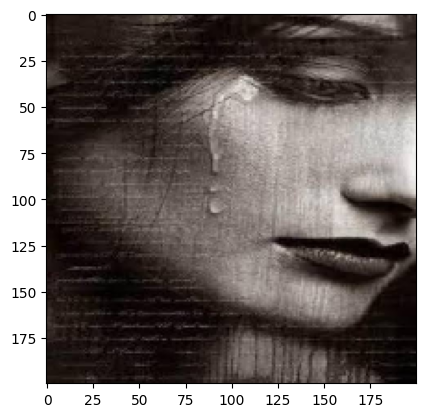

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
 i am not happy


In [ ]:
dir_path = '/content/drive/MyDrive/Happy or Sad/Testing'
for i in os.listdir(dir_path):
  img = image.load_img(dir_path+'//'+i,target_size=(200,200))
  plt.imshow(img)
  plt.show()

  x = image.img_to_array(img)
  x = np.expand_dims(x,axis=0)
  images = np.vstack([x])

  val = model.predict(images)
  if val == 0:
    print(' i am happy')
  else:
    print(' i am not happy')

In [ ]:
import gradio as gr
from PIL import Image
import numpy as np

def predict_mood(image):
    # Resize the image to (200, 200) as expected by the model
    img = image.resize((200, 200))
    # Convert the image to a numpy array
    x = np.array(img)
    # Expand dimensions to create a batch of 1 image
    x = np.expand_dims(x, axis=0)
    # Normalize the image (if the model was trained with normalized inputs)
    # The model was trained with rescale=1/200, so we should apply the same scaling here.
    x = x / 200.0
    # Make prediction
    val = model.predict(x)[0][0]
    # Interpret the prediction
    if val < 0.5:
        return 'Happy'
    else:
        return 'Not Happy'

In [ ]:
iface = gr.Interface(fn=predict_mood,
                     inputs=gr.Image(type="pil", label="Upload an image"),
                     outputs=gr.Label(label = "Predicted Mood"),
                     title = "Mood Classification(Happy/Not Happy)",
                     description = "Upload an image to classify if the person is happy or not happy")

In [ ]:
iface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://98742e6c466ac4a71f.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
